# **MODELO CLASIFICATORIO DE CALIDAD DE MANZANAS**

In [1]:
# Instalación de librerías básicas
!pip install torch torchvision pandas numpy matplotlib scikit-learn seaborn

## **CARGAR ARCHIVOS CSV DE GITHUB**

In [2]:
import pandas as pd

def load_data_from_github():
    try:
        #URLs Raw de archivos de github
        dataset_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/dataset_manzanas.csv"
        rangos_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/AppleQualTags.csv"

        print("Cargando datos...")

        dataset = pd.read_csv(dataset_url, sep=',')
        rangos = pd.read_csv(rangos_url, sep=';')

        print(f"Dataset cargado: {dataset.shape}")
        print(f"Rangos cargados: {rangos.shape}")

        return dataset, rangos

    except Exception as e:
        print(f"Error: {e}")
        return None, None

## **CREAR CSV CON 10 MUESTRAS PARA CLASIFICAR**

In [3]:
def crear_test_rapido():
    """Todo en una función."""
    dataset, _ = load_data_from_github()
    
    if dataset is not None:
        # Tomar 10 muestras, guardar solo Apple, Dry matter y bandas
        test = dataset.sample(10, random_state=42)
        bandas = [c for c in test.columns if str(c).replace('.', '').isdigit() and c != 'Dry matter']
        test[['Apple', 'Dry matter'] + sorted(bandas)].to_csv("test_rapido.csv", index=False)
        print("test_rapido.csv creado con 10 muestras")
        return True
    return False

# Ejecutar
crear_test_rapido()

Cargando datos...
Dataset cargado: (240, 143)
Rangos cargados: (4, 3)
test_rapido.csv creado con 10 muestras


True

## Cargar datos desde GitHub

In [4]:
dataset_df, ranks_df = load_data_from_github()

print("Columnas en dataset_df:", dataset_df.columns.tolist())
print("Columnas en ranks_df:", ranks_df.columns.tolist())

# Si 'Dry matter' no existe, busca el nombre correcto
if 'Dry matter' not in dataset_df.columns:
    print("Busca la columna equivalente a 'Dry matter' en:")
    print(dataset_df.columns.tolist())

Cargando datos...
Dataset cargado: (240, 143)
Rangos cargados: (4, 3)
Columnas en dataset_df: ['Apple', 'Dry matter', '430', '434', '438', '442', '446', '450', '454', '458', '462', '466', '470', '474', '478', '482', '486', '490', '494', '498', '502', '506', '510', '514', '518', '522', '526', '530', '534', '538', '542', '546', '550', '554', '558', '562', '566', '570', '574', '578', '582', '586', '590', '594', '598', '602', '606', '610', '614', '618', '622', '626', '630', '634', '638', '642', '646', '650', '654', '658', '662', '666', '670', '674', '678', '682', '686', '690', '694', '698', '702', '706', '710', '714', '718', '722', '726', '730', '734', '738', '742', '746', '750', '754', '758', '762', '766', '770', '774', '778', '782', '786', '790', '794', '798', '802', '806', '810', '814', '818', '822', '826', '830', '834', '838', '842', '846', '850', '854', '858', '862', '866', '870', '874', '878', '882', '886', '890', '894', '898', '902', '906', '910', '914', '918', '922', '926', '930', 

In [5]:
display(ranks_df)

,Category,Min_DryM,Max_DryM
0,Optima,0.1600,0.2200
1,Estándar,0.1400,0.1600
2,Aceptable,0.1298,0.1400
3,Inaceptable,0.1200,0.1298


## ASIGNAR CATEGORÍA DEL APPLEQUALTAGS.CSV

In [6]:
def define_categories(dry_matter, ranks_df):
    for _, fila in ranks_df.iterrows():
        if fila['Min_DryM'] <= dry_matter <= fila['Max_DryM']:
            return fila['Category']
    return 'Desconocida'

dataset_df['Category'] = dataset_df['Dry matter'].apply(
    lambda x: define_categories(x, ranks_df)
)

##  DISTRIBUCIÓN DE CATEGORIAS

In [7]:
print(dataset_df['Category'].value_counts())

Category
Estándar     156
Optima        76
Aceptable      8
Name: count, dtype: int64


## CODIFICACIÓN TEMPORAL PARA ESTRATIFICAR

In [8]:
category_map = {
    'Optima': 0,
    'Estándar': 1,
    'Aceptable': 2,
    'Inaceptable': 3
}

dataset_df['strat_label'] = dataset_df['Category'].map(category_map)

# X e y GLOBAL
X = dataset_df.drop(columns=['Category','strat_label'])
y = dataset_df['strat_label']

# CHECKPOINT
print(dataset_df[['Category','strat_label']].head())

   Category  strat_label
0    Optima            0
1  Estándar            1
2    Optima            0
3  Estándar            1
4    Optima            0


## Definición de X y Y globales

In [9]:
X = dataset_df.drop(columns=['Category', 'strat_label'])
y = dataset_df['strat_label']

# **DEFINICIÓN DE LA ARQUITECTURA DEL MLP**

In [10]:
import torch.nn as nn

class MLP_Apple(nn.Module):

    def __init__(self, input_size, hidden_layers, outputs_size, activation='relu', dropout_rate=0.2):
        super().__init__()

        layers = []
        prev_size = input_size

        # Función de activación
        act_map = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid()
        }
        act = act_map[activation]

        # Hidden layers
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(act)
            layers.append(nn.Dropout(dropout_rate))
            prev_size = h

        layers.append(nn.Linear(prev_size, outputs_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


## STRATIFIED K-FOLD

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## CHECKPOINT — Validación de folds

In [12]:
from collections import defaultdict

fold_counts = []

for i, (train_idx, val_idx) in enumerate(
        skf.split(dataset_df, dataset_df['strat_label'])):

    print(f"\nFOLD {i+1}")

    train_counts = dataset_df.iloc[train_idx]['Category'].value_counts()
    val_counts   = dataset_df.iloc[val_idx]['Category'].value_counts()

    print("TRAIN", train_counts)
    print("VAL", val_counts)

    for cat in dataset_df['Category'].unique():

        fold_counts.append({
            "fold": i+1,
            "category": cat,
            "train_samples": train_counts.get(cat, 0),
            "val_samples": val_counts.get(cat, 0)
        })



FOLD 1
TRAIN Category
Estándar     125
Optima        60
Aceptable      7
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       16
Aceptable     1
Name: count, dtype: int64

FOLD 2
TRAIN Category
Estándar     124
Optima        61
Aceptable      7
Name: count, dtype: int64
VAL Category
Estándar     32
Optima       15
Aceptable     1
Name: count, dtype: int64

FOLD 3
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64

FOLD 4
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64

FOLD 5
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64


In [13]:
# Verificar cuales son los folds consolidados
fold_df = pd.DataFrame(fold_counts)
print(fold_df.head())

   fold   category  train_samples  val_samples
0     1     Optima             60           16
1     1   Estándar            125           31
2     1  Aceptable              7            1
3     2     Optima             61           15
4     2   Estándar            124           32


In [14]:
# Promediado de los folds por muestra

mean_df = fold_df.groupby("category")[["train_samples", "val_samples"]].mean().reset_index()

mean_df.to_csv("prom_muestras_Apple.csv", index=False)

## **GRAFICA DE MUESTRAS PROMEDIOS POR FOLDS**

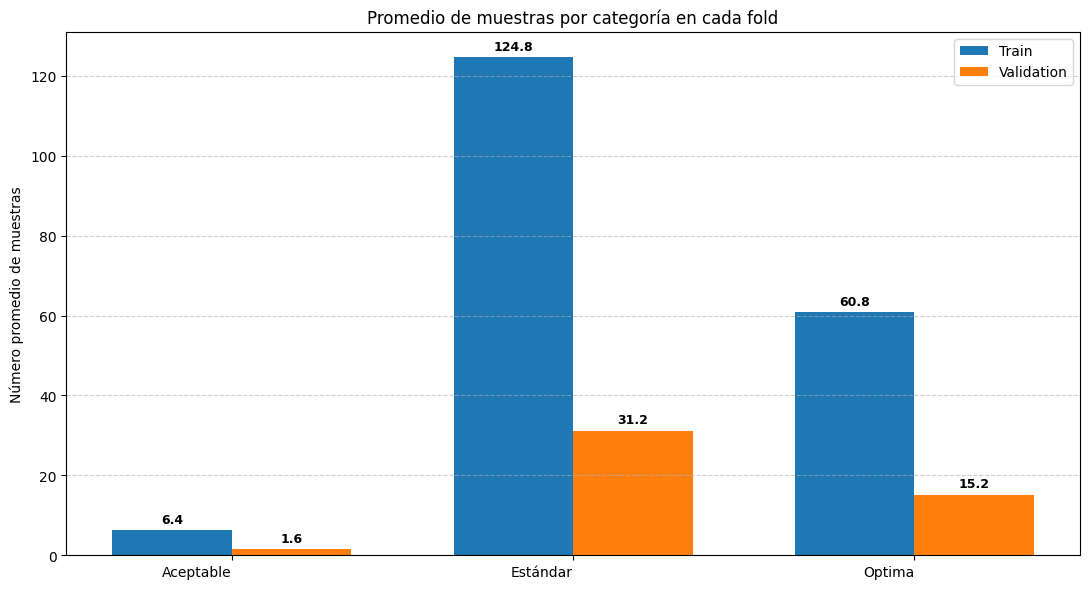

In [15]:
# Graficar estos promedios
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(11,6))

# Barras
bars_train = plt.bar(
    x - width/2,
    mean_df["train_samples"],
    width,
    label="Train"
)

bars_val = plt.bar(
    x + width/2,
    mean_df["val_samples"],
    width,
    label="Validation"
)

# Etiquetas en cada barra
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),                 
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

autolabel(bars_train)
autolabel(bars_val)

# Ejes
plt.xticks(x, mean_df["category"], ha='right')
plt.ylabel("Número promedio de muestras")
plt.title("Promedio de muestras por categoría en cada fold")

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()

# **ENTRENAMIENTO Y OPTIMIZACIÓN DEL MODELO**

## DICIONARIO DE OPTIMIZADORES

In [16]:
import torch.optim as optim 

OPTIMIZERS = {
    
    'adam': lambda params, lr: optim.Adam(params, lr=lr),
    
    'sgd': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    
    'rmsprop': lambda params, lr: optim.RMSprop(params, lr=lr),
   
    'adamW': lambda params, lr: optim.AdamW(params, lr=lr) 
}

## DICCIONARIO DE FUNCIONES DE PERDIDA

In [17]:
CRITERIONS = {
    # Entropia cruzada
    'cross_entropy': nn.CrossEntropyLoss, #Recomendada segun lo que he probado

    'weighted_ce': lambda w=None: nn.CrossEntropyLoss(weight=w),
    '''
    La pérdida de probabilidad logarítmica negativa. Es útil entrenar una clasificación problema con C clases. 
    (NLLLoss - Pytorch2.9 documentation, 2023)
    '''
    'nll': nn.NLLLoss,  
}

# FUNCIÓN DE ENTRENAMIENTO DEL MLP

In [18]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class Trainer:
    def __init__(self, model, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)

        self.history = {
            'train_loss': [],
            'train_accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

    # CONFIGURACION 
    def setup(self, 
              optimizer_name='adam', 
              criterion_name='cross_entropy', 
              lr=1e-4, 
              class_weight=None):

        if optimizer_name not in OPTIMIZERS:
            raise ValueError(f"Optimizador no soportado: {optimizer_name}")

        self.optimizer = OPTIMIZERS[optimizer_name](self.model.parameters(), lr)

        # Criterion
        if criterion_name == "weighted_ce":
            self.criterion = CRITERIONS["weighted_ce"](class_weight)
        else:
            self.criterion = CRITERIONS[criterion_name]()
    
    # ENTRENAMIENTO 
    def train_epoch(self, loader):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in loader:
            x = x.to(self.device)
            y = y.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(x)
            loss = self.criterion(logits, y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total   += y.size(0)

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy 

    # VALIDACION 
    def validate(self, loader):
        self.model.eval()

        total_loss = 0
        all_y = []
        all_pred = []

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                logits = self.model(x)
                loss = self.criterion(logits, y)

                preds = logits.argmax(dim=1)

                total_loss += loss.item()

                all_y.extend(y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(all_y, all_pred)
        prec = precision_score(all_y, all_pred, average='macro', zero_division=0)
        rec = recall_score(all_y, all_pred, average='macro', zero_division=0)
        f1 = f1_score(all_y, all_pred, average='macro', zero_division=0)

        return total_loss / len(loader), acc, prec, rec, f1

    #TRAINING LOOP 
    def train(self, train_loader, val_loader, epochs=50):

        for epoch in range(epochs):

            train_loss, train_acc = self.train_epoch(train_loader)

            val_loss, acc, prec, rec, f1 = self.validate(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(acc)
            self.history['val_precision'].append(prec)
            self.history['val_recall'].append(rec)
            self.history['val_f1'].append(f1)

            if epoch % 10 == 0:
                print(
                    f"Epoch {epoch:3d} | "
                    f"Train: {train_loss:.3f} | "
                    f"Val: {val_loss:.3f} | "
                    f"Acc: {acc:.3f} | "
                    f"F1: {f1:.3f}"
                )

        return self.history
    
    # PREDICCION PARA EVALUACION  
    def predict(self, loader):

        self.model.eval()

        all_preds = []
        all_true = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                preds = logits.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_true.extend(y.cpu().numpy())

        return all_true, all_preds

# OVERSAMPLING

## DICCIONARIO DE OVERSAMPLERS

In [19]:
from imblearn.over_sampling import RandomOverSampler, SMOTE #instalar

OVERSAMPLERS = {
    "none": None, #Sin oversampling
    "ros": RandomOverSampler,
    'smote': SMOTE

}

## FUNCIÓN PARA OVERSAMPLING

In [20]:
def apply_oversampling(X, y, method="none", random_state=42):

    if method == "none":
        return X, y
    
    if method not in OVERSAMPLERS:
        raise ValueError(f"Oversampler no soportado {method}")
    
    sampler = OVERSAMPLERS[method](random_state=random_state)

    X_res, Y_res = sampler.fit_resample(X, y)

    return X_res, Y_res

## CONFIGURACION DE MLP PARA MANZANA

In [21]:
MODEL_CONFIG = {
    "Modelo_P1": {
        "hidden_layers": [64],
        "activation": 'sigmoid',
        "dropout": 0.35,
        "epochs": 150,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'cross_entropy', 
        "lr": 1e-4, 
        "class_weight": None
    },

    "Modelo_PA": {
        "hidden_layers": [64, 32],
        "activation": 'tanh',
        "dropout": 0.3,
        "epochs": 100,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adamW', 
        "criterion": 'cross_entropy', 
        "lr": 1e-3, 
        "class_weight": 'balanced'
    },

    "Modelo_A1": {
        "hidden_layers": [128, 64],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 200,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'cross_entropy', 
        "lr": 1e-4, 
        "class_weight": None
    },

    "Modelo_A2": {
        "hidden_layers": [128, 64, 32],
        "activation": 'relu',
        "dropout": 0.4,
        "epochs": 200,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'weighted_ce', 
        "lr": 1e-4, 
        "class_weight": None
    },
    "Modelo_A3": {
        "hidden_layers": [64],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 180,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adamW', 
        "criterion": 'cross_entropy', 
        "lr": 1e-4, 
        "class_weight": None
    },
    "Modelo_A4": {
        "hidden_layers": [128, 64],
        "activation": 'tanh',
        "dropout": 0.2,
        "epochs": 180,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'rmsprop', 
        "criterion": 'cross_entropy', 
        "lr": 1e-4, 
        "class_weight": None
    },

}

## LOOP PARA FOLD

In [22]:
from  torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
# Revisar lo hay en x y y
# print("X: ", X.shape)
# print("Y: ", y.shape)
trained_models = {}

for model_name, config in MODEL_CONFIG.items():

    print(f"EJECUTANDO {model_name}")
    # Lista de metricas para folds
    metrics_all_folds_Apple = []
    train_losses_all = []
    val_losses_all = []
    all_y_true = []
    all_y_pred = []


# loop del fold
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        print(f"{'='*7} FOLD {fold} {'='*7}")

        #Paso #1: División del dataset_df
        X_train = X.iloc[train_idx]
        X_val   = X.iloc[val_idx]

        Y_train = y.iloc[train_idx]
        Y_val   = y.iloc[val_idx]  

        #Paso #2: Limpieza de las bandas
        spectral_bands = [c for c in X_train.columns if c not in ['Apple']] 

        X_train_clean = X_train[spectral_bands]
        X_val_clean = X_val[spectral_bands]

        #Paso 4: Definición de los inputs de la red (Bandas espectrales)
        num_feactures = X_train_clean.shape[1]

        #Paso 5: Normalización - Buscando mejorar el rendimiento del modelo
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_clean) 
        X_val_scaled = scaler.transform(X_val_clean)

        # Paso 6: OVERSAMPLING
        X_train_ros, Y_train_ros = apply_oversampling(
            X_train_scaled,
            Y_train,
            method=config['oversamplers']
        )

        # Paso 6.5 – Calcular pesos de clase
        classes = np.unique(Y_train_ros)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=Y_train_ros
        )

        class_weights = torch.tensor(class_weights, dtype=torch.float32)  

        # Paso 7: Tensores
        X_train_tensor = torch.FloatTensor(X_train_ros)
        X_val_tensor = torch.FloatTensor(X_val_scaled)

        Y_train_tensor = torch.LongTensor(Y_train_ros.values)
        Y_val_tensor = torch.LongTensor(Y_val.values)

        # Paso 8: Creación de dataset y loader
        train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
        
        # Paso 9: Modelo + entrenamiento 
        model = MLP_Apple(
            input_size=num_feactures,
            hidden_layers=config['hidden_layers'],
            outputs_size=3, #Si el dataset tuviera especies en la categoria inaceptable colocar 4
            activation=config['activation'],       
            dropout_rate=config['dropout']    
        )

        trainer = Trainer(model)
        trained_models[model_name] = trainer
        trainer.setup(config['optimizer'], config['criterion'], config['lr'], class_weights)

        history = trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            epochs = config['epochs']
        )

        y_true, y_pred = trainer.predict(val_loader)

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        # Paso 10: Guardar metricas
        for epoch in range(len(history['train_loss'])):

            metrics_all_folds_Apple.append({
                "model": model_name,
                "fold": fold + 1,
                "epoch": epoch,

                "train_loss": history["train_loss"][epoch],
                "train_accuracy": history["train_accuracy"][epoch],

                "val_loss": history["val_loss"][epoch],
                "val_accuracy": history["val_accuracy"][epoch],
                "val_precision": history["val_precision"][epoch],
                "val_recall": history["val_recall"][epoch],
                "val_f1": history["val_f1"][epoch]               
            })

    #EXPORTAR CSV DE METRICAS POR MODELO 
    df = pd.DataFrame(metrics_all_folds_Apple)

    csv_filename = f"metrics_{model_name}.csv"

    df.to_csv(csv_filename, index=False)

    print(f"CSV guardado: {csv_filename}")
    
    #EXPORTAR CSV PARA MATRIX DE CONFUSION 
    csv_filename_con = f"confusion_{model_name}.csv"

    pd.DataFrame({
        'y_true': all_y_true,
        'y_pred': all_y_pred
    }).to_csv(csv_filename_con, index=False)

    print(f"CSV guardado: {csv_filename_con}")

EJECUTANDO Modelo_P1
======= FOLD 1 =======
Epoch   0 | Train: 1.177 | Val: 1.345 | Acc: 0.333 | F1: 0.167
Epoch  10 | Train: 1.103 | Val: 1.228 | Acc: 0.271 | F1: 0.158
Epoch  20 | Train: 1.074 | Val: 1.148 | Acc: 0.292 | F1: 0.191
Epoch  30 | Train: 1.057 | Val: 1.095 | Acc: 0.354 | F1: 0.307
Epoch  40 | Train: 1.024 | Val: 1.060 | Acc: 0.333 | F1: 0.262
Epoch  50 | Train: 1.025 | Val: 1.038 | Acc: 0.354 | F1: 0.275
Epoch  60 | Train: 1.020 | Val: 1.024 | Acc: 0.354 | F1: 0.275
Epoch  70 | Train: 1.004 | Val: 1.017 | Acc: 0.354 | F1: 0.275
Epoch  80 | Train: 1.003 | Val: 1.007 | Acc: 0.354 | F1: 0.275
Epoch  90 | Train: 0.982 | Val: 1.001 | Acc: 0.375 | F1: 0.290
Epoch 100 | Train: 0.990 | Val: 0.997 | Acc: 0.375 | F1: 0.287
Epoch 110 | Train: 0.976 | Val: 0.992 | Acc: 0.375 | F1: 0.287
Epoch 120 | Train: 0.963 | Val: 0.987 | Acc: 0.417 | F1: 0.317
Epoch 130 | Train: 0.963 | Val: 0.982 | Acc: 0.417 | F1: 0.312
Epoch 140 | Train: 0.962 | Val: 0.974 | Acc: 0.458 | F1: 0.345
======= FOL

## PROMEDIO POR METRICAS DE MODELO

In [23]:
model_files = {
    "P1": "metrics_Modelo_P1.csv",
    "PA": "metrics_Modelo_PA.csv",
    "A1": "metrics_Modelo_A1.csv",
    "A2": "metrics_Modelo_A2.csv",
    "A3": "metrics_Modelo_A3.csv",
    "A4": "metrics_Modelo_A4.csv",
}

def calcular_promedios_por_modelo(csv_path):

    df = pd.read_csv(csv_path)

    last_epochs = df.groupby("fold").tail(1)

    mean_metrics = last_epochs[
        ["val_accuracy", "val_precision", "val_recall", "val_f1"]
    ].mean()

    return mean_metrics

# EJECUCIÓN AUTOMÁTICA

for model_name, csv_file in model_files.items():
    print(f"\nMetricas del modelo {model_name}")
    result = calcular_promedios_por_modelo(csv_file)
    print(result)


Metricas del modelo P1
val_accuracy     0.462500
val_precision    0.429589
val_recall       0.387164
val_f1           0.366396
dtype: float64

Metricas del modelo PA
val_accuracy     0.920833
val_precision    0.787079
val_recall       0.827939
val_f1           0.793358
dtype: float64

Metricas del modelo A1
val_accuracy     0.850000
val_precision    0.724101
val_recall       0.751922
val_f1           0.720116
dtype: float64

Metricas del modelo A2
val_accuracy     0.787500
val_precision    0.660077
val_recall       0.779928
val_f1           0.679746
dtype: float64

Metricas del modelo A3
val_accuracy     0.654167
val_precision    0.524693
val_recall       0.597473
val_f1           0.522608
dtype: float64

Metricas del modelo A4
val_accuracy     0.870833
val_precision    0.734024
val_recall       0.867339
val_f1           0.761957
dtype: float64


## **GRAFICA DE COMPARACIÓN DE DESEMPEÑO ENTRE TRES MODELOS**

  Modelo  Accuracy  Precision    Recall        F1
0     P1  0.390611   0.403222  0.341168  0.308448
1     PA  0.796000   0.694679  0.784245  0.684871
2     A4  0.711458   0.627992  0.775449  0.614849


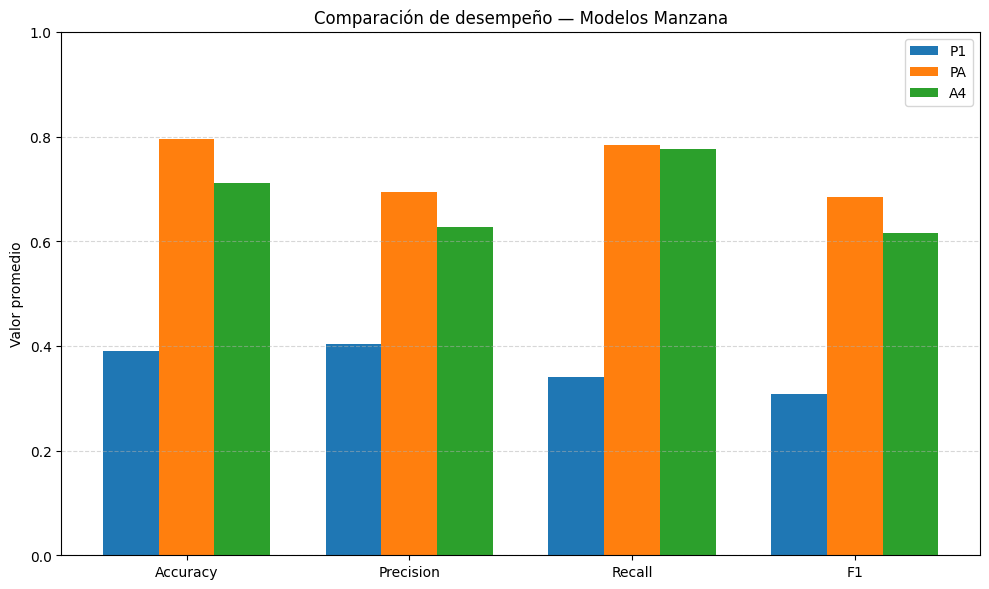

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "P1": "metrics_Modelo_P1.csv",
    "PA": "metrics_Modelo_PA.csv",
    "A4": "metrics_Modelo_A4.csv",
}

metrics = []

for name, file in files.items():
    df = pd.read_csv(file)

    summary = df[[
        'val_accuracy',
        'val_precision',
        'val_recall',
        'val_f1'
    ]].mean()

    metrics.append({
        "Modelo": name,
        "Accuracy": summary['val_accuracy'],
        "Precision": summary['val_precision'],
        "Recall": summary['val_recall'],
        "F1": summary['val_f1']
    })


final_df = pd.DataFrame(metrics)

print(final_df)

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model in enumerate(final_df['Modelo']):
    values = final_df.loc[
        final_df['Modelo'] == model,
        metrics_names
    ].values.flatten()

    plt.bar(x + i * width, values, width, label=model)

plt.xticks(x + width, metrics_names)
plt.ylim(0, 1)

plt.ylabel("Valor promedio")
plt.title("Comparación de desempeño — Modelos Manzana")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **GRAFICOS DE LOSS Y ACUARRY**

Graficas para el modelo P1


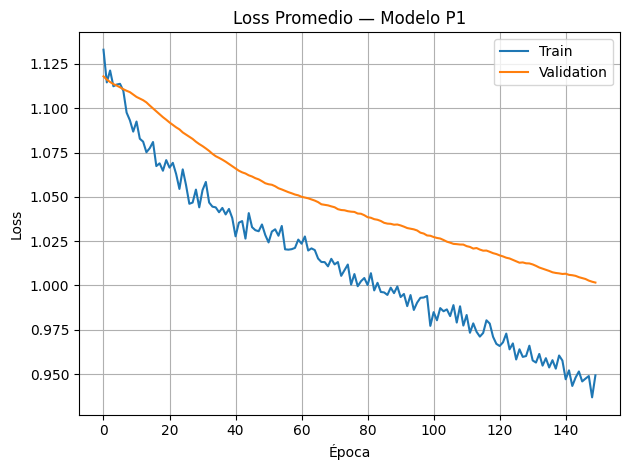

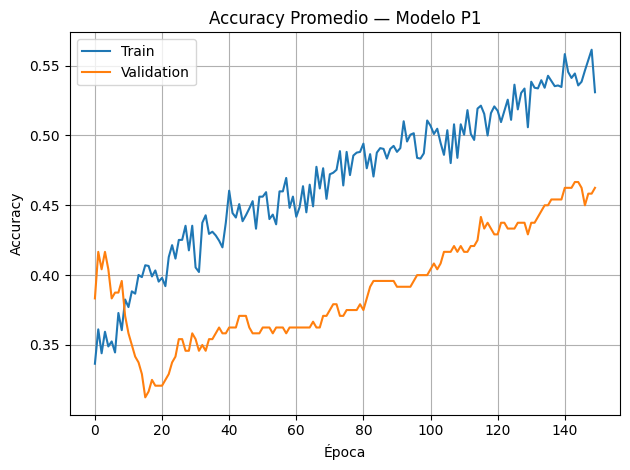

Graficas para el modelo PA


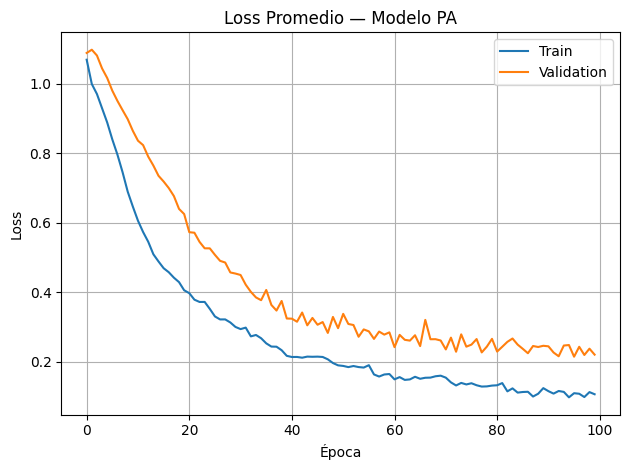

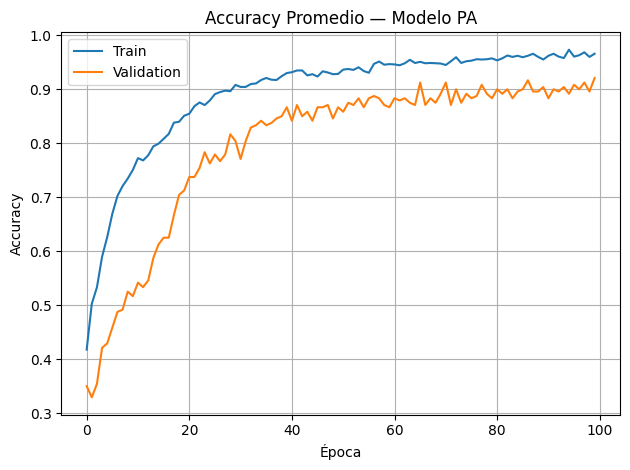

Graficas para el modelo A1


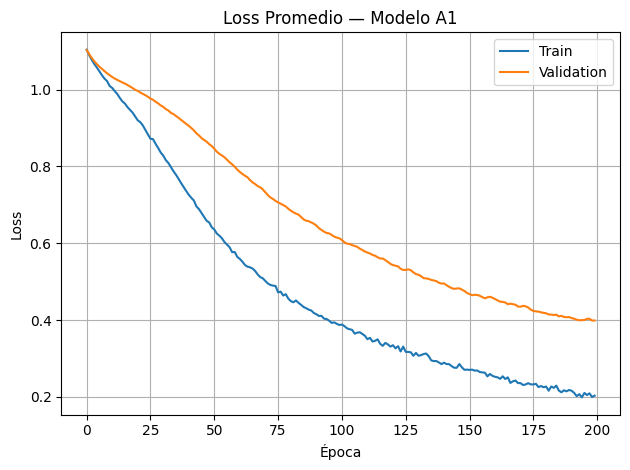

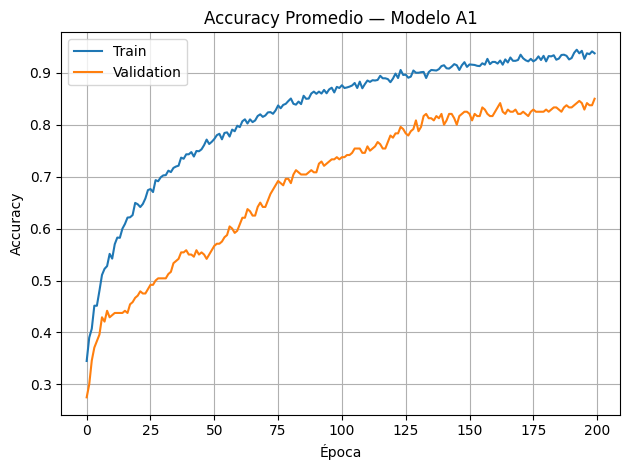

Graficas para el modelo A2


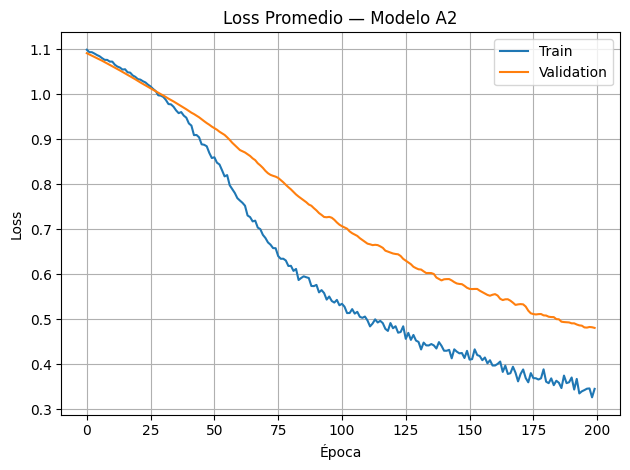

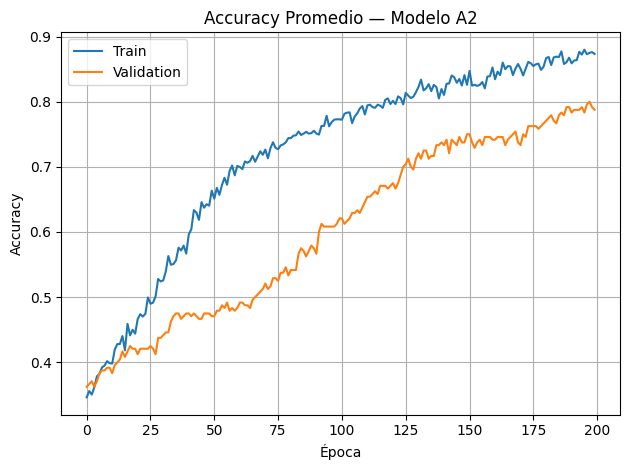

Graficas para el modelo A3


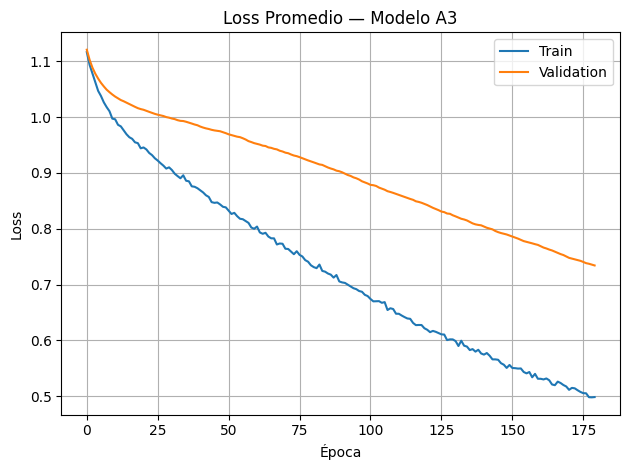

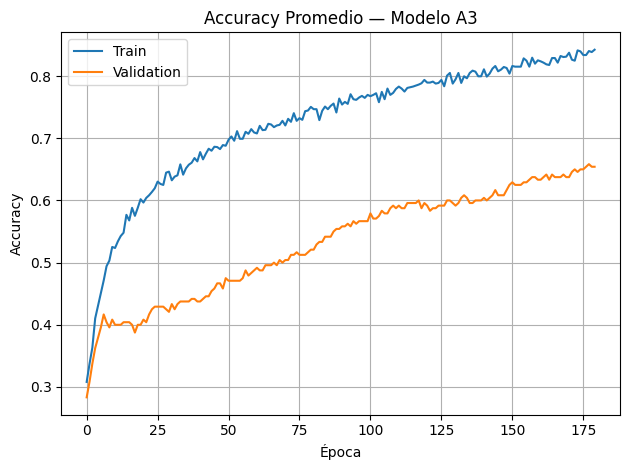

Graficas para el modelo A4


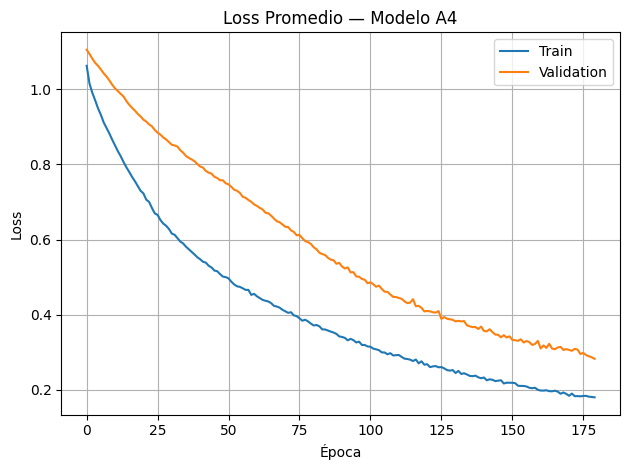

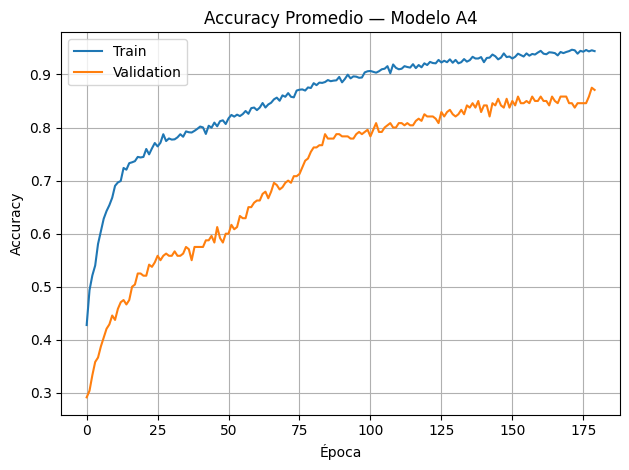

In [25]:
model_files = {
    "P1": "metrics_Modelo_P1.csv",
    "PA": "metrics_Modelo_PA.csv",
    "A1": "metrics_Modelo_A1.csv",
    "A2": "metrics_Modelo_A2.csv",
    "A3": "metrics_Modelo_A3.csv",
    "A4": "metrics_Modelo_A4.csv",
}

def plot_model_metrics(model_name, csv_path):

    df = pd.read_csv(csv_path)

    # Promedio por época (consolidando folds)
    mean_epoch = df.groupby("epoch").mean(numeric_only=True)

    #LOSS 
    plt.figure()

    plt.plot(mean_epoch["train_loss"], label="Train")
    plt.plot(mean_epoch["val_loss"], label="Validation")

    plt.title(f"Loss Promedio — Modelo {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # ACCURACY 
    if "train_accuracy" in mean_epoch.columns:

        plt.figure()

        plt.plot(mean_epoch["train_accuracy"], label="Train")
        plt.plot(mean_epoch["val_accuracy"], label="Validation")

        plt.title(f"Accuracy Promedio — Modelo {model_name}")
        plt.xlabel("Época")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

# EJECUCIÓN AUTOMÁTICA

for model_name, csv_file in model_files.items():
    print(f"Graficas para el modelo {model_name}")
    plot_model_metrics(model_name, csv_file)

# MATRIZ DE CONFUSIÓN

Graficas para el modelo PA


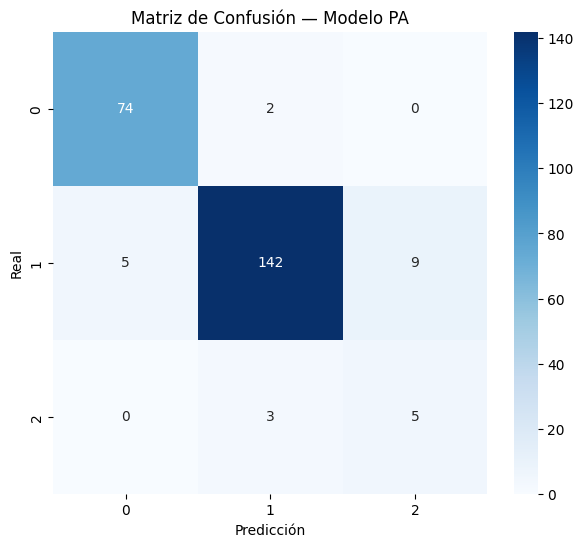

Graficas para el modelo P1


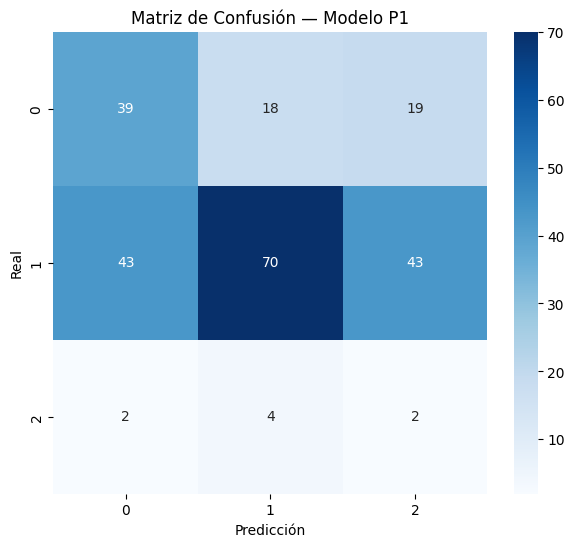

Graficas para el modelo M3


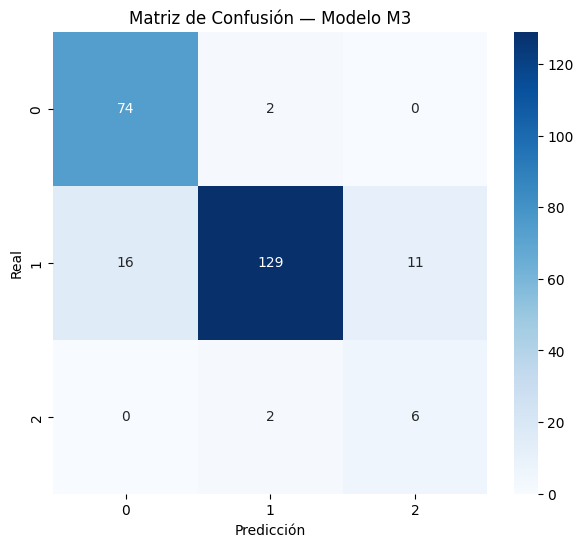

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

model_files = {
    "PA": "confusion_Modelo_PA.csv",
    "P1": "confusion_Modelo_P1.csv",
    "M3": "confusion_Modelo_A4.csv"
}

def plot_model_confusion(model_name, csv_path):
  df = pd.read_csv(csv_path)

  cm = confusion_matrix(df['y_true'], df['y_pred'])

  plt.figure(figsize=(7,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f"Matriz de Confusión — Modelo {model_name}")
  plt.xlabel("Predicción")
  plt.ylabel("Real")
  plt.show()


for model_name, csv_file in model_files.items():
    print(f"Graficas para el modelo {model_name}")
    plot_model_confusion(model_name, csv_file)
